What are we going to learn today?
In this article, we will learn to detect and treat outliers in Pandas. Outliers are values in the data set that are very large or small compared to the majority of the values in the data set. For example, 367 is an outlier in the following data set (3,6,1,4,5,3,2,1, 367).

Why is it important to learn?
The machine learning model performance depends on how clean your data is. Even the best machine learning algorithm will not perform well if outliers are present in the data. Outliers affect the training process of a machine learning model, and results can be inaccurate.

How are we going to achieve today’s learning goal?
Today’s learning plan is:

Detecting outliers with Visualization
Detecting outliers with Z-score
Detecting outliers with Inter Quartile Range — IQR
Treating/Cleaning Outlier

Let us import the Pandas, Numpy and Seaborn libraries. Seaborn is a new library that we have not used in the part articles. It is a library for data visualization in Python.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

We will be using the Titanic data set, which can be downloaded from here.

In [3]:
df = pd.read_csv('../train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Detecting outliers with Visualization
The easiest way to see the outliers is by using a box plot. A box has two main components a ‘box’ and two ‘whiskers’. The whiskers represent the data outside the middle 50% of the data. Data values that lie outside the whiskers are considered outliers.

Lets make out first box plot with columns, Age and Fare, to visualize the outlier.

<Axes: ylabel='Age'>

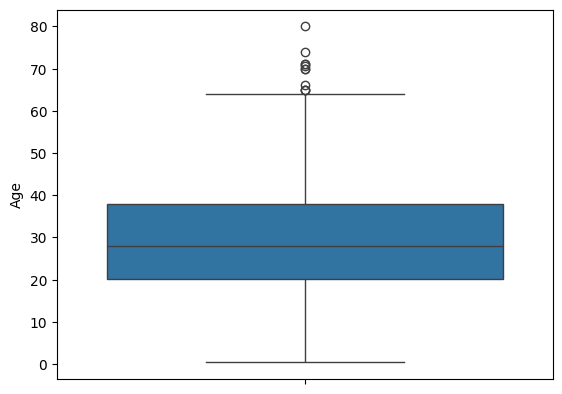

In [4]:
sns.boxplot(y=df['Age'])

The values above 65 in the Age column are outliers.

<Axes: ylabel='Fare'>

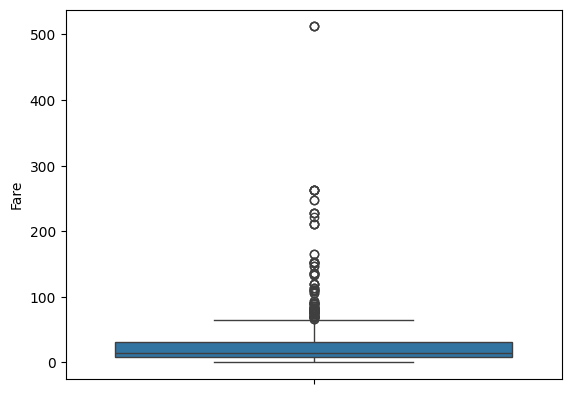

In [5]:
sns.boxplot(y=df['Fare'])

The values above 80 in the Fare column are outliers.

Detecting outliers with Z score
In statistics, Z-score is used to find outliers in a data set. It is a statistical measurement that helps us understand how close or far we are from the data set’s arithmetic mean. For people who don’t have a statistics background, all you have to remember is “ any value that greater than +3 and less than -3 standard deviation is an outlier value.”

The best way to visualize this concept is by looking at a normal distribution. The x-axis in the figure below represents the standard deviation (a measure of variability in statistics). Observe the data outside the standard deviation of +3 and -3 is considered as outliers.

Now lets calculate the outlier values. To detect outliers in pandas using Z score , we set a limit for any values outside of +3/-3 standard deviations from the mean to be considered outliers.
    This can be achieved with Pandas methods mean, and std (standard deviation).

In [7]:
upper_limit = df['Age'].mean() + 3* df['Age'].std() # Right from the mean
lower_limit = df['Age'].mean() - 3 * df['Age'].std() # Left from the mean
print(upper_limit)
print(lower_limit)

73.27860964406094
-13.880374349943303


So, we got 72.74 and -12 values. We will ignore -12 because the Age can not be -12. Let’s check how many outliers are in the Age column with the help of the loc method.

In [8]:
df.loc[df['Age'] >= upper_limit, 'Age']

630    80.0
851    74.0
Name: Age, dtype: float64

Detecting outliers with Interquartile Range (IQR)
In statistics, the interquartile range is a measure of statistical dispersion, which describes the variability in data. To find an IQR, we calculate Q1 and Q3 values then find the IQR by subtracting Q3 from Q1. Q3 is the 75th percentile, and Q1 is the 25th percentile.

To find Q3 and Q1, we use Pandas quantile method and pass 0.75 and 0.25 values which are 75th and 25th percentile.

In [11]:
IQR = df['Fare'].quantile(0.75) - df['Fare'].quantile(0.25)
IQR

np.float64(23.0896)

Now we will use the outlier formula, which you can see in the figure. 1.5 is the constant used to determine outliers.

Lower Outlier = Q1-(1.5 x IQR)

Upper Outlier =Q3-(1.5 x IQR)

A resulting value from these formulas that is greater than a higher outlier, and less than a lower outlier is considered as an outlier.

Let’s use the formulas.

In [12]:
Higher_outlier = df['Fare'].quantile(0.75) + (IQR * 1.5)
lower_outlier = df['Fare'].quantile(0.25) - (IQR * 1.5)
print(Higher_outlier)
print(lower_outlier)

65.6344
-26.724


We got 66.8 and -27 values. We will ignore -27 because Fare can not be -27. Let’s check how many outliers are in the Fare column with the loc method.

In [13]:
df.loc[df['Fare'] >= Higher_outlier, 'Fare']

1       71.2833
27     263.0000
31     146.5208
34      82.1708
52      76.7292
         ...   
846     69.5500
849     89.1042
856    164.8667
863     69.5500
879     83.1583
Name: Fare, Length: 116, dtype: float64

Treating/Cleaning Outlier
So far, we have detected the outliers, and we will overwrite them with a higher outlier.

In the Age column we will use the Z score upper_limit of 72 to replace the outliers.

In [14]:
df.loc[df['Age'] >= upper_limit, 'Age'] = 72

In the Fare column we will use the IQR higher_outlier of 149 to replace the outliers.

In [17]:
df.loc[df['Fare'] >= Higher_outlier, 'Fare'] = 149